In [4]:
import pandas as pd


In [10]:
df = pd.read_csv('../data/results.csv')

In [12]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [14]:
df.shape

(49287, 9)

In [16]:
df.columns.tolist()

['date',
 'home_team',
 'away_team',
 'home_score',
 'away_score',
 'tournament',
 'city',
 'country',
 'neutral']

In [18]:
df['tournament'].unique()[:30]   # show first 30 to avoid clutter

array(['Friendly', 'British Home Championship', 'Évence Coppée Trophy',
       'Muratti Vase', 'Copa Lipton', 'Copa Newton',
       'Copa Premio Honor Argentino', 'Olympic Games',
       'Copa Premio Honor Uruguayo', 'Far Eastern Championship Games',
       'Copa Roca', 'Copa América', 'Inter-Allied Games', 'Peace Cup',
       'Open International Championship', 'Soccer Ashes',
       'Copa Chevallier Boutell', 'Nordic Championship',
       'Central European International Cup', 'Baltic Cup', 'Balkan Cup',
       'Central American and Caribbean Games', 'FIFA World Cup',
       'Copa Rio Branco', 'FIFA World Cup qualification',
       'Bolivarian Games', 'CCCF Championship', 'NAFC Championship',
       'Copa Oswaldo Cruz', 'Asian Games'], dtype=object)

In [20]:
world_cup_df = df[df['tournament'] == 'FIFA World Cup']
world_cup_df.shape

(1036, 9)

In [22]:
print("Earliest:", world_cup_df['date'].min())
print("Latest:",   world_cup_df['date'].max())

Earliest: 1930-07-13
Latest: 2026-06-27


In [24]:
world_cup_df[world_cup_df['date'] > '2022-12-31'].head(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49215,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49216,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
49217,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
49218,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
49219,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True
49220,2026-06-13,Brazil,Morocco,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49221,2026-06-13,Haiti,Scotland,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49222,2026-06-13,Australia,Turkey,NaN,NaN,FIFA World Cup,Vancouver,Canada,True
49223,2026-06-14,Germany,Curaçao,NaN,NaN,FIFA World Cup,Houston,United States,True
49224,2026-06-14,Ivory Coast,Ecuador,NaN,NaN,FIFA World Cup,Philadelphia,United States,True


In [28]:
# Convert the 'date' column to proper datetime format
world_cup_df['date'] = pd.to_datetime(world_cup_df['date'])

/var/folders/bz/8kbj9jln5hx_yqm6slqjr2sh0000gn/T/ipykernel_7838/583295094.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  world_cup_df['date'] = pd.to_datetime(world_cup_df['date'])


In [30]:
historical_df = world_cup_df[world_cup_df['date'].dt.year <= 2022]
future_fixtures_df = world_cup_df[world_cup_df['date'].dt.year >= 2026]

In [32]:
# Clean historical (drop missing scores)
historical_df = historical_df.dropna(subset=['home_score', 'away_score'])

In [34]:
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'home_win'
    elif row['home_score'] < row['away_score']:
        return 'away_win'
    else:
        return 'draw'

historical_df['result'] = historical_df.apply(get_result, axis=1)

print("--- Historical Data (for training) ---")
print(f"Rows: {len(historical_df)}")
print(historical_df['result'].value_counts())

print("\n--- 2026 Fixtures (to predict) ---")
print(f"Rows: {len(future_fixtures_df)}")
print(future_fixtures_df[['date', 'home_team', 'away_team']].head())


--- Historical Data (for training) ---
Rows: 964
result
home_win    439
away_win    311
draw        214
Name: count, dtype: int64

--- 2026 Fixtures (to predict) ---
Rows: 72
            date      home_team               away_team
49215 2026-06-11         Mexico            South Africa
49216 2026-06-11    South Korea          Czech Republic
49217 2026-06-12         Canada  Bosnia and Herzegovina
49218 2026-06-12  United States                Paraguay
49219 2026-06-13          Qatar             Switzerland


In [36]:
# If neutral = False, the home team is playing at home (advantage = 1)
# If neutral = True, it's a neutral venue (advantage = 0)

historical_df['home_advantage'] = historical_df['neutral'].apply(lambda x: 0 if x == True else 1)


In [38]:
# Check the distribution
print(historical_df['home_advantage'].value_counts())
print("\nHome advantage impact on win rate:")
print(historical_df.groupby('home_advantage')['result'].value_counts(normalize=True).unstack())

home_advantage
0    843
1    121
Name: count, dtype: int64

Home advantage impact on win rate:
result          away_win      draw  home_win
home_advantage                              
0               0.339265  0.227758  0.432977
1               0.206612  0.181818  0.611570


In [40]:
# 1. Home team win rate
home_stats = historical_df.groupby('home_team')['result'].apply(
    lambda x: (x == 'home_win').sum() / len(x)
).reset_index(name='home_team_win_rate')


In [42]:
# 2. Away team win rate
away_stats = historical_df.groupby('away_team')['result'].apply(
    lambda x: (x == 'away_win').sum() / len(x)
).reset_index(name='away_team_win_rate')

In [44]:
# 3. Merge both rates back into historical_df
historical_df = historical_df.merge(home_stats, on='home_team', how='left')
historical_df = historical_df.merge(away_stats, on='away_team', how='left')


In [46]:
# 4. Create a composite strength feature: home strength vs. away strength
historical_df['home_strength'] = historical_df['home_team_win_rate']
historical_df['away_strength'] = historical_df['away_team_win_rate']

In [48]:
# Preview
historical_df[['home_team', 'away_team', 'home_strength', 'away_strength', 'result']].head(10)

,home_team,away_team,home_strength,away_strength,result
0,Belgium,United States,0.535714,0.260870,away_win
1,France,Mexico,0.636364,0.242424,home_win
2,Brazil,Yugoslavia,0.666667,0.392857,away_win
3,Peru,Romania,0.200000,0.357143,away_win
4,Argentina,France,0.646154,0.379310,home_win
5,Chile,Mexico,0.428571,0.242424,home_win
6,Bolivia,Yugoslavia,0.000000,0.392857,away_win
7,Paraguay,United States,0.250000,0.260870,away_win
8,Uruguay,Peru,0.400000,0.307692,home_win
9,Argentina,Mexico,0.646154,0.242424,home_win


In [50]:
# Fill missing win rates with 0.33 (baseline equal win/draw/loss)
historical_df['home_strength'] = historical_df['home_strength'].fillna(0.33)
historical_df['away_strength'] = historical_df['away_strength'].fillna(0.33)

# Verify no more missing values
print(historical_df[['home_strength', 'away_strength']].isnull().sum())

home_strength    0
away_strength    0
dtype: int64


#### preparing the feature matrix

In [54]:
feature_columns = ['home_advantage', 'home_strength', 'away_strength']
X = historical_df[feature_columns]

In [56]:
y = historical_df['result']

In [58]:
print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features shape: (964, 3)
Target distribution:
result
home_win    439
away_win    311
draw        214
Name: count, dtype: int64


In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # ensures reproducibility
    stratify=y           # keeps the class proportions the same in both sets
)

In [62]:
print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 771
Test set size: 193


In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [66]:
# Initialize the model
model = RandomForestClassifier(
    n_estimators=100,    # 100 trees in the forest
    random_state=42,     # for reproducibility
    class_weight='balanced'  # adjust for the mild imbalance we saw
)


In [68]:
# Train on the training set
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [70]:
# Predict on the test set
y_pred = model.predict(X_test)

In [72]:
# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred, labels=['home_win', 'away_win', 'draw']))

Accuracy: 0.513

Classification Report:
               precision    recall  f1-score   support

    away_win       0.55      0.50      0.53        62
        draw       0.27      0.26      0.26        43
    home_win       0.59      0.65      0.62        88

    accuracy                           0.51       193
   macro avg       0.47      0.47      0.47       193
weighted avg       0.51      0.51      0.51       193

Confusion Matrix:
 [[57 12 19]
 [20 31 11]
 [19 13 11]]


#### What did model learn from (features)

In [75]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
feature_names = X.columns

In [77]:
# Sort descending
indices = np.argsort(importances)[::-1]

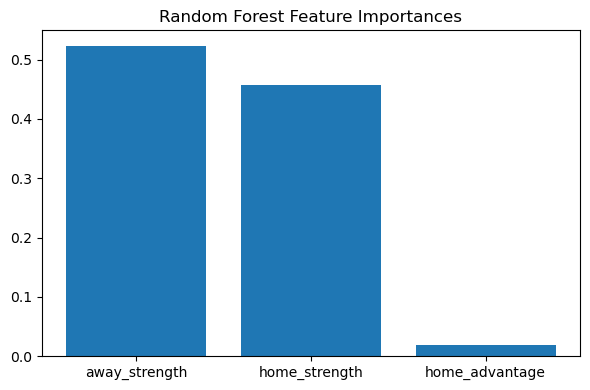

In [79]:
plt.figure(figsize=(6,4))
plt.title("Random Forest Feature Importances")
plt.bar(range(len(feature_names)), importances[indices], align='center')
plt.xticks(range(len(feature_names)), feature_names[indices], rotation=0)
plt.tight_layout()
plt.show()

In [81]:
for name, imp in zip(feature_names[indices], importances[indices]):
    print(f"{name}: {imp:.4f}")

away_strength: 0.5233
home_strength: 0.4572
home_advantage: 0.0195


In [83]:
# Prepare the 2026 fixture features
future_X = future_fixtures_df.copy()

In [85]:
# Home advantage
future_X['home_advantage'] = future_X['neutral'].apply(lambda x: 0 if x == True else 1)

In [87]:
# Team strengths (fill missing with 0.33)
home_strength_map = historical_df.groupby('home_team')['home_strength'].max()
away_strength_map = historical_df.groupby('away_team')['away_strength'].max()


In [89]:
future_X['home_strength'] = future_X['home_team'].map(home_strength_map).fillna(0.33)
future_X['away_strength'] = future_X['away_team'].map(away_strength_map).fillna(0.33)


In [91]:
# Predict probabilities
probs = model.predict_proba(future_X[feature_columns])


In [93]:
# Combine with fixture info
predictions_df = future_fixtures_df[['date', 'home_team', 'away_team']].copy()
for i, cls in enumerate(model.classes_):
    predictions_df[cls] = probs[:, i]

print(predictions_df.head(10))

            date      home_team               away_team  away_win      draw  \
49215 2026-06-11         Mexico            South Africa  0.000000  0.159970   
49216 2026-06-11    South Korea          Czech Republic  0.260000  0.090000   
49217 2026-06-12         Canada  Bosnia and Herzegovina  0.300000  0.290000   
49218 2026-06-12  United States                Paraguay  0.150000  0.606724   
49219 2026-06-13          Qatar             Switzerland  1.000000  0.000000   
49220 2026-06-13         Brazil                 Morocco  0.012556  0.007444   
49221 2026-06-13          Haiti                Scotland  0.082414  0.797586   
49222 2026-06-13      Australia                  Turkey  0.627331  0.010000   
49223 2026-06-14        Germany                 Curaçao  0.016789  0.763027   
49224 2026-06-14    Ivory Coast                 Ecuador  0.260030  0.010000   

       home_win  
49215  0.840030  
49216  0.650000  
49217  0.410000  
49218  0.243276  
49219  0.000000  
49220  0.980000  
4922

In [ ]:
#### A Smarter Default for Unknown Teams

In [95]:
# Find the first World Cup appearance for every team
first_appearance = {}
for _, row in historical_df.iterrows():
    home_team = row['home_team']
    away_team = row['away_team']
    year = row['date'].year
    
    if home_team not in first_appearance:
        first_appearance[home_team] = year
    if away_team not in first_appearance:
        first_appearance[away_team] = year

In [97]:
# Tag matches where the home/away team is making its debut
def is_debut(team, match_year):
    return first_appearance.get(team, 9999) == match_year

historical_df['home_is_debut'] = historical_df.apply(
    lambda row: is_debut(row['home_team'], row['date'].year), axis=1)
historical_df['away_is_debut'] = historical_df.apply(
    lambda row: is_debut(row['away_team'], row['date'].year), axis=1)


In [99]:
# Calculate debutant win rates
debut_home_results = historical_df[historical_df['home_is_debut']]['result'].value_counts(normalize=True)
debut_away_results = historical_df[historical_df['away_is_debut']]['result'].value_counts(normalize=True)

In [101]:
print("Debutant Home Team Results:")
print(debut_home_results)
print("\nDebutant Away Team Results:")
print(debut_away_results)

Debutant Home Team Results:
result
away_win    0.509259
home_win    0.342593
draw        0.148148
Name: proportion, dtype: float64

Debutant Away Team Results:
result
home_win    0.561290
away_win    0.283871
draw        0.154839
Name: proportion, dtype: float64


In [103]:
# Goal difference per match (from the home team's perspective)
historical_df['goal_diff'] = historical_df['home_score'] - historical_df['away_score']

# Average goal difference for each team as home and away
home_gd = historical_df.groupby('home_team')['goal_diff'].mean().reset_index()
home_gd.columns = ['team', 'avg_home_gd']

away_gd = historical_df.groupby('away_team')['goal_diff'].mean().reset_index()
away_gd.columns = ['team', 'avg_away_gd']

# For the away team, goal_diff is negative when they lose, so we flip perspective
# Actually, let's just create a net strength metric per team
team_gd = pd.merge(home_gd, away_gd, on='team', how='outer').fillna(0)
team_gd['avg_gd'] = (team_gd['avg_home_gd'] - team_gd['avg_away_gd']) / 2
# Negative because away_gd is from home's perspective

print(team_gd.sort_values('avg_gd', ascending=False).head(10))
print("\nBottom 10 teams:")
print(team_gd.sort_values('avg_gd', ascending=True).head(10))

           team  avg_home_gd  avg_away_gd    avg_gd
75       Turkey     3.000000     0.000000  1.500000
81   Yugoslavia     2.600000     0.000000  1.300000
8        Brazil     1.149425    -1.074074  1.111750
33      Hungary     1.800000    -0.176471  0.988235
28      Germany     1.025641    -0.647059  0.836350
46  Netherlands     0.733333    -0.880000  0.806667
60       Russia     1.235294    -0.071429  0.653361
56     Portugal     1.500000     0.210526  0.644737
26       France     1.090909    -0.103448  0.597179
39        Italy     0.714286    -0.470588  0.592437

Bottom 10 teams:
                    team  avg_home_gd  avg_away_gd    avg_gd
20              DR Congo    -2.500000         9.00 -5.750000
31                 Haiti    -7.000000         2.50 -4.750000
35             Indonesia     0.000000         6.00 -3.000000
24           El Salvador    -2.000000         3.80 -2.900000
77  United Arab Emirates    -2.000000         3.50 -2.750000
13              China PR    -2.000000       

In [105]:
# Build head-to-head win ratio
h2h_records = {}
for (home, away), group in historical_df.groupby(['home_team', 'away_team']):
    home_wins = (group['result'] == 'home_win').sum()
    total = len(group)
    h2h_records[(home, away)] = home_wins / total if total > 0 else 0.5

# Function to look up H2H
def get_h2h(home, away):
    direct = h2h_records.get((home, away), None)
    reverse = h2h_records.get((away, home), None)
    if direct is not None:
        return direct
    elif reverse is not None:
        return 1 - reverse  # flip perspective
    else:
        return 0.5  # never met

historical_df['h2h_win_ratio'] = historical_df.apply(
    lambda row: get_h2h(row['home_team'], row['away_team']), axis=1)

print(historical_df[['home_team', 'away_team', 'h2h_win_ratio']].head(10))
print(f"\nUnique H2H pairs with history: {len(h2h_records)}")

   home_team      away_team  h2h_win_ratio
0    Belgium  United States       0.500000
1     France         Mexico       0.500000
2     Brazil     Yugoslavia       0.250000
3       Peru        Romania       0.000000
4  Argentina         France       0.666667
5      Chile         Mexico       1.000000
6    Bolivia     Yugoslavia       0.000000
7   Paraguay  United States       0.000000
8    Uruguay           Peru       1.000000
9  Argentina         Mexico       1.000000

Unique H2H pairs with history: 731


In [107]:
# Debutant default values (from our analysis)
DEBUT_HOME_WIN = 0.34   # home win rate for a debutant playing at home
DEBUT_AWAY_WIN = 0.28   # away win rate for a debutant playing away

# Recalculate home_strength and away_strength with smarter defaults
home_strength_map = historical_df.groupby('home_team')['home_strength'].max()
away_strength_map = historical_df.groupby('away_team')['away_strength'].max()

def get_home_strength(team):
    return home_strength_map.get(team, DEBUT_HOME_WIN)

def get_away_strength(team):
    return away_strength_map.get(team, DEBUT_AWAY_WIN)


In [109]:
# Map each team's average goal difference
team_gd_dict = team_gd.set_index('team')['avg_gd'].to_dict()
# Default for unknown teams: slightly worse than the worst known team (≈ -2.0)
UNKNOWN_GD = -2.0

historical_df['home_gd'] = historical_df['home_team'].map(team_gd_dict).fillna(UNKNOWN_GD)
historical_df['away_gd'] = historical_df['away_team'].map(team_gd_dict).fillna(UNKNOWN_GD)


In [111]:
feature_columns = [
    'home_advantage',
    'home_strength', 'away_strength',
    'home_gd', 'away_gd',
    'h2h_win_ratio'
]

X = historical_df[feature_columns]
y = historical_df['result']

# Re‑split with the same random state to keep comparability
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set size:", len(X_train))

Training set size: 771


In [113]:
model_v2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
model_v2.fit(X_train, y_train)

y_pred_v2 = model_v2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_v2))
print(classification_report(y_test, y_pred_v2))
print(confusion_matrix(y_test, y_pred_v2, labels=['home_win', 'away_win', 'draw']))

# Feature importance
for name, imp in zip(feature_columns, model_v2.feature_importances_):
    print(f"{name}: {imp:.4f}")

Accuracy: 0.6994818652849741
              precision    recall  f1-score   support

    away_win       0.64      0.69      0.67        62
        draw       0.49      0.44      0.46        43
    home_win       0.84      0.83      0.83        88

    accuracy                           0.70       193
   macro avg       0.66      0.65      0.65       193
weighted avg       0.70      0.70      0.70       193

[[73  6  9]
 [ 8 43 11]
 [ 6 18 19]]
home_advantage: 0.0325
home_strength: 0.1311
away_strength: 0.1557
home_gd: 0.1445
away_gd: 0.1397
h2h_win_ratio: 0.3964


In [115]:
# Build features for 2026 fixtures
future_X = future_fixtures_df.copy()
future_X['home_advantage'] = future_X['neutral'].apply(lambda x: 0 if x else 1)
future_X['home_strength'] = future_X['home_team'].apply(get_home_strength)
future_X['away_strength'] = future_X['away_team'].apply(get_away_strength)
future_X['home_gd'] = future_X['home_team'].map(team_gd_dict).fillna(UNKNOWN_GD)
future_X['away_gd'] = future_X['away_team'].map(team_gd_dict).fillna(UNKNOWN_GD)

# Head-to-head for 2026
future_X['h2h_win_ratio'] = future_X.apply(
    lambda row: get_h2h(row['home_team'], row['away_team']), axis=1)

probs_v2 = model_v2.predict_proba(future_X[feature_columns])
for i, cls in enumerate(model_v2.classes_):
    future_X[cls] = probs_v2[:, i]

# Show some key matches
print(future_X[['date', 'home_team', 'away_team', 'home_win', 'draw', 'away_win']].head(10))

            date      home_team               away_team  home_win      draw  \
49215 2026-06-11         Mexico            South Africa  0.950000  0.040000   
49216 2026-06-11    South Korea          Czech Republic  0.406606  0.093246   
49217 2026-06-12         Canada  Bosnia and Herzegovina  0.369303  0.220115   
49218 2026-06-12  United States                Paraguay  0.931397  0.068603   
49219 2026-06-13          Qatar             Switzerland  0.268580  0.179341   
49220 2026-06-13         Brazil                 Morocco  1.000000  0.000000   
49221 2026-06-13          Haiti                Scotland  0.225766  0.136463   
49222 2026-06-13      Australia                  Turkey  0.281403  0.065929   
49223 2026-06-14        Germany                 Curaçao  0.349663  0.117305   
49224 2026-06-14    Ivory Coast                 Ecuador  0.399380  0.259983   

       away_win  
49215  0.010000  
49216  0.500149  
49217  0.410582  
49218  0.000000  
49219  0.552079  
49220  0.000000  
4922

In [117]:
## Still solving the Curacao problem

In [119]:
# Find the row for Germany vs Curaçao
germany_row = future_X[(future_X['home_team'] == 'Germany') & (future_X['away_team'] == 'Curaçao')]
print(germany_row[['home_team', 'away_team'] + feature_columns].to_string())

      home_team away_team  home_advantage  home_strength  away_strength  home_gd  away_gd  h2h_win_ratio
49223   Germany   Curaçao               0       0.628205           0.28  0.83635     -2.0            0.5


In [121]:
# Germany's stats in our training data
germany_stats = historical_df[(historical_df['home_team'] == 'Germany') | (historical_df['away_team'] == 'Germany')]
print(f"Germany's total matches: {len(germany_stats)}")
print("Home strength:", get_home_strength('Germany'))
print("Away strength:", get_away_strength('Germany'))
print("Goal diff:", team_gd_dict.get('Germany', 'default'))

# Curaçao stats
print(f"\nCuraçao matches: {len(historical_df[(historical_df['home_team'] == 'Curaçao') | (historical_df['away_team'] == 'Curaçao')])}")
print("Home strength:", get_home_strength('Curaçao'))
print("Away strength:", get_away_strength('Curaçao'))
print("Goal diff:", team_gd_dict.get('Curaçao', 'default'))

Germany's total matches: 112
Home strength: 0.6282051282051282
Away strength: 0.5588235294117647
Goal diff: 0.8363499245852186

Curaçao matches: 0
Home strength: 0.34
Away strength: 0.28
Goal diff: default


In [ ]:
### Strength‑Based H2H Prior

In [123]:
import numpy as np

In [125]:
# 1. Build expected win probability from goal difference
# Using a simple logistic function: p = 1 / (1 + exp(-(home_gd - away_gd)))
# The difference (home_gd - away_gd) is positive when home is stronger.
# We'll scale it appropriately so that typical differences map to realistic probabilities.
# For reference, a difference of 2 goals roughly corresponds to ~88% win chance in football.

def expected_win_prob(home_gd_val, away_gd_val, scale=1.2):
    diff = home_gd_val - away_gd_val
    return 1 / (1 + np.exp(-scale * diff))

In [127]:
# 2. Redefine get_h2h to use actual history when available, else use strength-based prior
def get_h2h_smart(home, away, home_gd_val, away_gd_val):
    # Check actual history
    direct = h2h_records.get((home, away), None)
    reverse = h2h_records.get((away, home), None)
    if direct is not None:
        return direct
    elif reverse is not None:
        return 1 - reverse
    else:
        # Never met – use strength-based estimate
        return expected_win_prob(home_gd_val, away_gd_val)


In [129]:
# 3. Apply the new function to historical_df
historical_df['h2h_smart'] = historical_df.apply(
    lambda row: get_h2h_smart(row['home_team'], row['away_team'], 
                              row['home_gd'], row['away_gd']), axis=1)


In [131]:
# 4. Build updated feature set
feature_columns_smart = [
    'home_advantage',
    'home_strength', 'away_strength',
    'home_gd', 'away_gd',
    'h2h_smart'   # replaces h2h_win_ratio
]

X_smart = historical_df[feature_columns_smart]
y = historical_df['result']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_smart, y, test_size=0.2, random_state=42, stratify=y
)

In [133]:
# 5. Train new model
model_v3 = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced'
)
model_v3.fit(X_train_s, y_train_s)

y_pred_s = model_v3.predict(X_test_s)
print("Accuracy:", accuracy_score(y_test_s, y_pred_s))
print(classification_report(y_test_s, y_pred_s))


Accuracy: 0.6994818652849741
              precision    recall  f1-score   support

    away_win       0.64      0.69      0.67        62
        draw       0.49      0.44      0.46        43
    home_win       0.84      0.83      0.83        88

    accuracy                           0.70       193
   macro avg       0.66      0.65      0.65       193
weighted avg       0.70      0.70      0.70       193



In [135]:
# Feature importance
for name, imp in zip(feature_columns_smart, model_v3.feature_importances_):
    print(f"{name}: {imp:.4f}")


home_advantage: 0.0325
home_strength: 0.1311
away_strength: 0.1557
home_gd: 0.1445
away_gd: 0.1397
h2h_smart: 0.3964


In [137]:
## Repredict

In [140]:
# Prepare 2026 features using smart H2H
future_X_smart = future_fixtures_df.copy()
future_X_smart['home_advantage'] = future_X_smart['neutral'].apply(lambda x: 0 if x else 1)
future_X_smart['home_strength'] = future_X_smart['home_team'].apply(get_home_strength)
future_X_smart['away_strength'] = future_X_smart['away_team'].apply(get_away_strength)
future_X_smart['home_gd'] = future_X_smart['home_team'].map(team_gd_dict).fillna(UNKNOWN_GD)
future_X_smart['away_gd'] = future_X_smart['away_team'].map(team_gd_dict).fillna(UNKNOWN_GD)

future_X_smart['h2h_smart'] = future_X_smart.apply(
    lambda row: get_h2h_smart(row['home_team'], row['away_team'],
                              row['home_gd'], row['away_gd']), axis=1)

probs_smart = model_v3.predict_proba(future_X_smart[feature_columns_smart])

for i, cls in enumerate(model_v3.classes_):
    future_X_smart[cls] = probs_smart[:, i]

# Show Germany vs Curaçao specifically
germany_pred = future_X_smart[future_X_smart['home_team'] == 'Germany'][['home_team', 'away_team', 'home_win', 'draw', 'away_win']]
print("\nGermany vs Curaçao (fixed):")
print(germany_pred)

# And the top 10 overall
print("\nFirst 10 fixtures:")
print(future_X_smart[['date', 'home_team', 'away_team', 'home_win', 'draw', 'away_win']].head(10))


Germany vs Curaçao (fixed):
      home_team    away_team  home_win    draw  away_win
49223   Germany      Curaçao  0.980000  0.0000  0.020000
49247   Germany  Ivory Coast  0.745884  0.1274  0.126716

First 10 fixtures:
            date      home_team               away_team  home_win      draw  \
49215 2026-06-11         Mexico            South Africa  0.950000  0.040000   
49216 2026-06-11    South Korea          Czech Republic  0.020000  0.145125   
49217 2026-06-12         Canada  Bosnia and Herzegovina  0.110000  0.350000   
49218 2026-06-12  United States                Paraguay  0.931397  0.068603   
49219 2026-06-13          Qatar             Switzerland  0.245346  0.142576   
49220 2026-06-13         Brazil                 Morocco  1.000000  0.000000   
49221 2026-06-13          Haiti                Scotland  0.006062  0.200000   
49222 2026-06-13      Australia                  Turkey  0.020000  0.201953   
49223 2026-06-14        Germany                 Curaçao  0.980000  0.

In [142]:
# Save cleaned historical data for the next notebook
historical_df.to_pickle('../data/historical_wc_clean.pkl')


In [144]:
import joblib

# 1. The trained model
joblib.dump(model_v3, '../models/wc_predictor_v1.pkl')

# 2. The feature columns list
joblib.dump(feature_columns_smart, '../models/feature_columns.pkl')

# 3. The mapping dictionaries (wrapped in a single dict)
mappings = {
    'home_strength_map': home_strength_map,
    'away_strength_map': away_strength_map,
    'team_gd_dict': team_gd_dict,
    'h2h_records': h2h_records
}
joblib.dump(mappings, '../models/team_mappings.pkl')

print("All model artifacts saved to ../models/")

All model artifacts saved to ../models/


In [ ]:
## Test cells

In [146]:
# Test the predictor module
import sys
sys.path.append('../')  # so we can import from src
from src.predictor import predict_match

result = predict_match('Germany', 'Curaçao', neutral=True)
print(result)

{'away_win': 0.02, 'draw': 0.0, 'home_win': 0.98}
